# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:


Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
!pip install phik

In [2]:
!pip install pandas numpy matplotlib seaborn sqlalchemy psycopg2-binary phik python-dotenv

In [3]:
from phik import phik
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [5]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [6]:
db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME')
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string)

In [7]:
query = '''
SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    (
        p.created_dt_msk::date
        - LAG(p.created_dt_msk::date) OVER (
            PARTITION BY p.user_id
            ORDER BY p.created_dt_msk
        )
    )::int AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases p
JOIN afisha.events e
    ON p.event_id = e.event_id
JOIN afisha.city c
    ON e.city_id = c.city_id
JOIN afisha.regions r
    ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main <> 'фильм'
'''

In [8]:
df = pd.read_sql_query(query, con=engine)

In [9]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк


In [10]:
df.shape

(290611, 15)

> #### Вывод
>
> На данном этапе выполнена выгрузка данных из базы данных PostgreSQL и сформирован датасет для дальнейшего анализа пользовательского поведения.
>
> При подготовке выборки были сохранены только заказы, совершённые с мобильных устройств и стационарных компьютеров, а также исключены мероприятия категории «фильм» в соответствии с требованиями задания. Кроме того, был рассчитан дополнительный показатель `days_since_prev`, характеризующий интервал между соседними заказами пользователя.
>
> Итоговая выборка содержит **290 611 заказов** и **15 признаков**, описывающих пользователей, параметры заказов, характеристики мероприятий и место их проведения. Полученные данные соответствуют требованиям проекта и могут быть использованы на следующих этапах исследования.

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

In [12]:
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
dtype: int64

In [13]:
df.describe()

,order_id,revenue,tickets_count,days_since_prev,event_id
count,2.906110e+05,290611.000000,290611.000000,268678.000000,290611.000000
mean,4.326225e+06,625.584360,2.754311,3.222381,438019.834992
std,2.497551e+06,1227.693064,1.170620,11.350509,147423.078841
min,1.000000e+00,-90.760000,1.000000,0.000000,4436.000000
25%,2.163618e+06,116.850000,2.000000,0.000000,361772.000000
50%,4.326366e+06,356.010000,3.000000,0.000000,498275.000000
75%,6.488330e+06,810.130000,4.000000,1.000000,546287.000000
max,8.653108e+06,81174.540000,57.000000,148.000000,592325.000000


In [14]:
df.nunique()

user_id                   21933
device_type_canonical         2
order_id                 290611
order_dt                    153
order_ts                 280753
currency_code                 2
revenue                   42522
tickets_count                22
days_since_prev             149
event_id                  22427
event_name                15248
service_name                 36
event_type_main               7
region_name                  81
city_name                   352
dtype: int64

> #### Вывод
>
> На этапе первичного изучения данных была проверена структура датасета, типы данных и наличие пропущенных значений.
>
> В результате выгрузки была сформирована таблица размером **290 611 строк и 15 столбцов**. Объём данных является достаточным для проведения исследовательского анализа и построения пользовательских профилей.
>
> Большинство признаков не содержат пропусков. Единственным столбцом с пропущенными значениями является `days_since_prev`, в котором отсутствует **21 933 значения**. Это соответствует логике расчёта показателя, поскольку для первых заказов пользователей невозможно определить интервал с предыдущей покупкой.
>
> Типы данных в целом определены корректно. Столбцы `order_dt` и `order_ts` уже имеют формат даты и времени, а количественные показатели представлены числовыми типами данных. На этапе предобработки может потребоваться дополнительная оптимизация типов данных для снижения потребления памяти.
>
> Предварительный анализ показывает наличие особенностей в количественных признаках. В столбце `revenue` присутствуют отрицательные значения, а максимальная выручка существенно превышает медианное значение, что может свидетельствовать о наличии выбросов. Аналогично максимальное количество билетов в заказе достигает 57, что требует дополнительной проверки распределения данного признака.
>
> В данных представлены две валюты оплаты (`rub` и `kzt`), поэтому перед дальнейшим анализом необходимо привести выручку к единой валюте. Также на этапе предобработки следует проверить категориальные признаки на наличие некорректных значений и дополнительно изучить распределение количественных показателей.
>
> В целом структура и качество данных позволяют перейти к этапу предобработки и подготовки признаков для дальнейшего анализа поведения пользователей.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [15]:
tenge = pd.read_csv(
    'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'
)

tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [16]:
tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [17]:
df['order_dt'] = pd.to_datetime(df['order_dt'])
tenge['data'] = pd.to_datetime(tenge['data'])

In [18]:
df = df.merge(
    tenge[['data', 'curs']],
    left_on='order_dt',
    right_on='data',
    how='left'
)

In [19]:
df[['order_dt', 'currency_code', 'revenue', 'curs']].head()

,order_dt,currency_code,revenue,curs
0,2024-08-20,rub,1521.94,18.6972
1,2024-07-23,rub,289.45,18.3419
2,2024-10-06,rub,1258.57,19.6475
3,2024-07-13,rub,8.49,18.5010
4,2024-10-04,rub,1390.41,19.6648


In [20]:
df['revenue_rub'] = df['revenue']

mask = df['currency_code'] == 'kzt'

df.loc[mask, 'revenue_rub'] = (
    df.loc[mask, 'revenue']
    * df.loc[mask, 'curs']
    / 100
)

In [21]:
df[['currency_code', 'revenue', 'curs', 'revenue_rub']].sample(10)

,currency_code,revenue,curs,revenue_rub
275256,rub,49.03,19.8928,49.03
108370,rub,1445.80,19.5723,1445.80
61874,rub,17.28,18.4198,17.28
289735,rub,223.39,19.7185,223.39
25402,rub,201.01,19.8418,201.01
239635,rub,96.60,18.2738,96.60
146682,rub,652.34,18.2738,652.34
215564,rub,116.27,18.3129,116.27
75124,rub,1011.35,19.9266,1011.35
71650,rub,559.83,19.8829,559.83


In [22]:
df.groupby('currency_code')['revenue_rub'].describe()

,count,mean,std,min,25%,50%,75%,max
currency_code,,,,,,,,
kzt,5069.0,981.325159,975.240026,0.00,98.83172,734.654217,1419.633147,5256.843478
rub,285542.0,548.013929,871.750181,-90.76,114.17000,346.630000,793.320000,81174.540000


In [23]:
df = df.drop(columns=['data', 'curs'])

> #### Вывод
>
> В исходных данных выручка была представлена в двух валютах: российских рублях (`rub`) и казахстанских тенге (`kzt`). Для обеспечения корректного сравнения финансовых показателей выручка была приведена к единой валюте — российскому рублю.
>
> Для заказов, оплаченных в тенге, к данным были присоединены ежедневные курсы валют за 2024 год по дате оформления заказа. Поскольку курс был указан для 100 тенге, при пересчёте использовался соответствующий коэффициент.
>
> В результате был сформирован новый признак `revenue_rub`, содержащий выручку в российских рублях независимо от исходной валюты оплаты. Данный показатель будет использоваться в дальнейшем анализе вместо исходного столбца `revenue`.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  service_name           290611 non-null  object        
 12  event_type_main        290611 non-null  obje

In [25]:
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

In [26]:
df[['revenue_rub', 'tickets_count', 'days_since_prev']].describe()

,revenue_rub,tickets_count,days_since_prev
count,290611.000000,290611.000000,268678.000000
mean,555.571987,2.754311,3.222381
std,875.498172,1.170620,11.350509
min,-90.760000,1.000000,0.000000
25%,113.970000,2.000000,0.000000
50%,351.140000,3.000000,0.000000
75%,802.050000,4.000000,1.000000
max,81174.540000,57.000000,148.000000


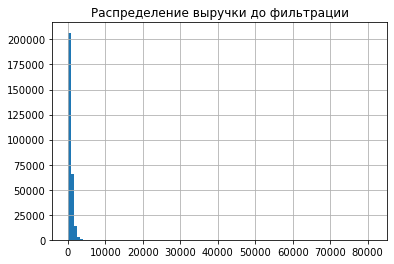

In [27]:
df['revenue_rub'].hist(bins=100)
plt.title('Распределение выручки до фильтрации')
plt.show()

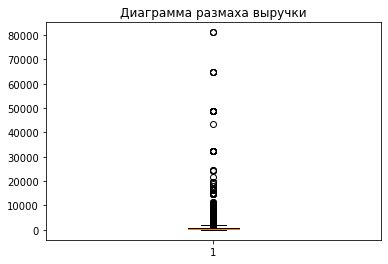

In [28]:
plt.boxplot(df['revenue_rub'])
plt.title('Диаграмма размаха выручки')
plt.show()

In [29]:
p99 = df['revenue_rub'].quantile(0.99)
p99

2628.4217390400004

In [30]:
rows_before = len(df)

df = df[df['revenue_rub'] <= p99]

rows_after = len(df)

print(f'До фильтрации: {rows_before}')
print(f'После фильтрации: {rows_after}')
print(f'Удалено строк: {rows_before - rows_after}')
print(f'Удалено: {(rows_before - rows_after) / rows_before:.2%}')

До фильтрации: 290611
После фильтрации: 287786
Удалено строк: 2825
Удалено: 0.97%


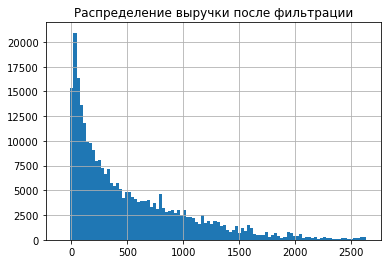

In [31]:
df['revenue_rub'].hist(bins=100)
plt.title('Распределение выручки после фильтрации')
plt.show()

> #### Вывод
>
> В ходе предобработки данных были проверены пропущенные значения, типы данных, категориальные признаки и распределения основных количественных показателей.
>
> Анализ пропусков показал, что отсутствующие значения присутствуют только в столбце `days_since_prev` (**21 933 наблюдения**). Такие пропуски являются ожидаемыми, поскольку для первых заказов пользователей невозможно рассчитать интервал с момента предыдущей покупки. В остальных признаках пропуски отсутствуют.
>
> Проверка типов данных показала, что структура датасета соответствует содержанию признаков. Столбцы с датами и временем уже представлены в формате `datetime`, а числовые показатели имеют корректные числовые типы данных. Дополнительно был сформирован новый признак `revenue_rub`, содержащий выручку, приведённую к единой валюте — российскому рублю.
>
> Анализ категориальных признаков не выявил значений, указывающих на отсутствие информации или ошибки заполнения данных. В выборке представлены два типа устройств, две валюты оплаты, семь типов мероприятий, 36 билетных операторов, 81 регион и 352 города.
>
> Исследование распределения выручки показало выраженную правостороннюю асимметрию и наличие выбросов. При медианном значении выручки около **351 руб.** максимальное значение превышало **81 тыс. руб.**, что могло существенно влиять на результаты дальнейшего анализа. Для снижения влияния экстремальных наблюдений была выполнена фильтрация по **99-му перцентилю** признака `revenue_rub`.
>
> Пороговое значение составило **2 628 руб.** После фильтрации было удалено **2 825 записей**, что соответствует **0,97%** исходной выборки. Таким образом, из анализа были исключены только наиболее экстремальные наблюдения, при этом основной объём данных был сохранён.
>
> В результате сформирована очищенная выборка, пригодная для дальнейшего анализа поведения пользователей, формирования пользовательских профилей и изучения факторов, влияющих на повторные покупки.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [32]:
df = df.sort_values(['user_id', 'order_ts'])

In [33]:
first_orders = (
    df.groupby('user_id')
      .first()
      .reset_index()
)

In [34]:
user_profile = (
    df.groupby('user_id')
      .agg(
          first_order_date=('order_dt', 'min'),
          last_order_date=('order_dt', 'max'),
          orders_count=('order_id', 'count'),
          avg_revenue=('revenue_rub', 'mean'),
          avg_tickets=('tickets_count', 'mean'),
          avg_days_between=('days_since_prev', 'mean')
      )
      .reset_index()
)

In [35]:
user_profile = user_profile.merge(
    first_orders[
        [
            'user_id',
            'device_type_canonical',
            'region_name',
            'service_name',
            'event_type_main'
        ]
    ],
    on='user_id',
    how='left'
)

In [36]:
user_profile = user_profile.rename(columns={
    'device_type_canonical': 'first_device',
    'region_name': 'first_region',
    'service_name': 'first_service',
    'event_type_main': 'first_event_type'
})

In [37]:
user_profile['is_two'] = (
    user_profile['orders_count'] >= 2
).astype(int)

user_profile['is_five'] = (
    user_profile['orders_count'] >= 5
).astype(int)

In [38]:
user_profile.head()

,user_id,first_order_date,last_order_date,orders_count,avg_revenue,avg_tickets,avg_days_between,first_device,first_region,first_service,first_event_type,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,1,0
2,000898990054619,2024-07-13,2024-10-23,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,1,0


In [39]:
user_profile.shape

(21854, 13)

> #### Вывод
>
> Для дальнейшего анализа поведения пользователей был сформирован агрегированный профиль каждого пользователя. В результате преобразования данные были переведены с уровня отдельных заказов на уровень пользователей: каждой строке итоговой таблицы соответствует один пользователь сервиса.
>
> Для каждого пользователя были рассчитаны характеристики, описывающие историю его взаимодействия с платформой:
>
> - дата первого и последнего заказа;
> - устройство, использованное при первом заказе;
> - регион проведения первого мероприятия;
> - билетный оператор первого заказа;
> - жанр первого посещённого мероприятия;
> - общее количество заказов;
> - средняя выручка с заказа;
> - среднее количество билетов в заказе;
> - среднее время между заказами.
>
> Дополнительно были сформированы бинарные признаки `is_two` и `is_five`, отражающие факт совершения пользователем двух и более либо пяти и более заказов соответственно. Эти признаки могут быть использованы в дальнейшем как целевые переменные для анализа факторов, связанных с повторными покупками.
>
> В результате был сформирован датасет, содержащий **21 854 пользовательских профиля** и **13 признаков**, характеризующих историю покупок и предпочтения пользователей сервиса.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [40]:
users_cnt = len(user_profile)

avg_revenue = user_profile['avg_revenue'].mean()

share_two = user_profile['is_two'].mean()

share_five = user_profile['is_five'].mean()

print('Пользователей:', users_cnt)
print('Средняя выручка:', avg_revenue)
print('Доля 2+ заказов:', share_two)
print('Доля 5+ заказов:', share_five)

Пользователей: 21854
Средняя выручка: 544.3980508974331
Доля 2+ заказов: 0.6170952686007138
Доля 5+ заказов: 0.2900613160062231


In [41]:
user_profile[
    ['orders_count', 'avg_tickets', 'avg_days_between']
].describe()

,orders_count,avg_tickets,avg_days_between
count,21854.000000,21854.000000,13521.000000
mean,13.168573,2.743129,15.836109
std,121.674800,0.913080,22.297926
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.000000
75%,5.000000,3.076923,20.400000
max,10181.000000,11.000000,148.000000


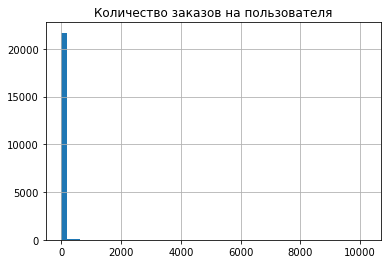

In [42]:
user_profile['orders_count'].hist(bins=50)
plt.title('Количество заказов на пользователя')
plt.show()

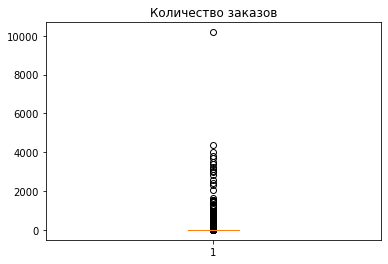

In [43]:
plt.boxplot(user_profile['orders_count'])
plt.title('Количество заказов')
plt.show()

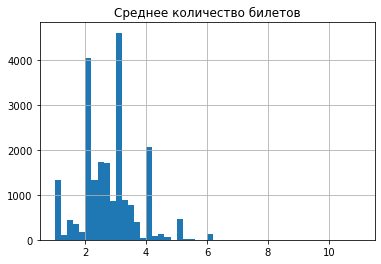

In [44]:
user_profile['avg_tickets'].hist(bins=50)
plt.title('Среднее количество билетов')
plt.show()

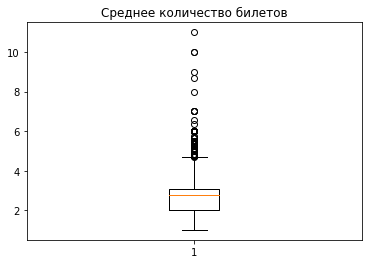

In [45]:
plt.boxplot(user_profile['avg_tickets'])
plt.title('Среднее количество билетов')
plt.show()

In [46]:
user_profile['orders_count'].describe(percentiles=[0.95, 0.99])

count    21854.000000
mean        13.168573
std        121.674800
min          1.000000
50%          2.000000
95%         31.350000
99%        152.000000
max      10181.000000
Name: orders_count, dtype: float64

In [47]:
user_profile['avg_tickets'].describe(percentiles=[0.95, 0.99])

count    21854.000000
mean         2.743129
std          0.913080
min          1.000000
50%          2.750000
95%          4.000000
99%          5.000000
max         11.000000
Name: avg_tickets, dtype: float64

In [48]:
orders_p99 = user_profile['orders_count'].quantile(0.99)

orders_p99

152.0

In [49]:
users_before = len(user_profile)

user_profile = user_profile[
    user_profile['orders_count'] <= orders_p99
]

users_after = len(user_profile)

print(users_before)
print(users_after)
print(users_before - users_after)
print(
    round(
        (users_before - users_after)
        / users_before * 100,
        2
    )
)

21854
21638
216
0.99


In [50]:
user_profile_filtered = user_profile[
    user_profile['orders_count'] <= user_profile['orders_count'].quantile(0.99)
].copy()

> #### Вывод
>
> После формирования пользовательских профилей в выборке содержалось **21 854 пользователя**. Средняя выручка с одного заказа составила **544 рубля**. Доля пользователей, совершивших не менее двух заказов, достигла **61,7%**, а доля пользователей с пятью и более заказами — **29,0%**, что свидетельствует о высокой доле повторных клиентов в выборке.
>
> Анализ распределения количества заказов показал наличие выраженной правосторонней асимметрии. Несмотря на то что медианное количество заказов составляет всего **2 заказа**, максимальное значение превышает **10 тысяч заказов** на одного пользователя. При этом 99% пользователей совершили не более **152 заказов**, что позволяет считать наблюдения выше данного порога нетипичными.
>
> Для снижения влияния экстремальных значений на результаты дальнейшего анализа была выполнена фильтрация по **99-му перцентилю** признака `orders_count`. В результате из выборки было исключено **216 пользователей** (**0,99%** от общего числа пользователей). После фильтрации в датасете осталось **21 638 пользователей**.
>
> Анализ среднего количества билетов на заказ не выявил критических аномалий. Несмотря на наличие отдельных высоких значений, максимальное среднее количество билетов составило **11**, что остаётся реалистичным для групповых и семейных покупок. Поэтому дополнительная фильтрация данного признака не проводилась.
>
> Полученная выборка является достаточно репрезентативной по объёму и лучше отражает поведение типичных пользователей сервиса, что позволит более корректно выполнить дальнейший исследовательский анализ.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [51]:
event_dist = (
    user_profile['first_event_type']
    .value_counts()
    .reset_index()
)

event_dist.columns = ['segment', 'users']

event_dist['share'] = (
    event_dist['users']
    / event_dist['users'].sum()
    * 100
)

event_dist

,segment,users,share
0,концерты,9560,44.181532
1,другое,5426,25.076255
2,театр,4239,19.590535
3,стендап,1110,5.129864
4,спорт,794,3.669470
5,выставки,414,1.913301
6,ёлки,95,0.439042


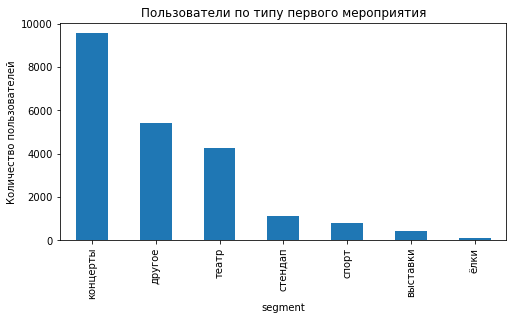

In [52]:
event_dist.plot(
    x='segment',
    y='users',
    kind='bar',
    legend=False,
    figsize=(8,4)
)

plt.title('Пользователи по типу первого мероприятия')
plt.ylabel('Количество пользователей')
plt.show()

In [53]:
device_dist = (
    user_profile['first_device']
    .value_counts()
    .reset_index()
)

device_dist.columns = ['segment', 'users']

device_dist['share'] = (
    device_dist['users']
    / device_dist['users'].sum()
    * 100
)

device_dist

,segment,users,share
0,mobile,17924,82.835752
1,desktop,3714,17.164248


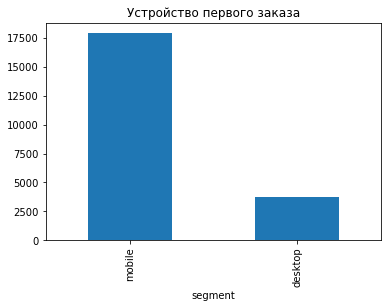

In [54]:
device_dist.plot(
    x='segment',
    y='users',
    kind='bar',
    legend=False
)

plt.title('Устройство первого заказа')
plt.show()

In [55]:
region_dist = (
    user_profile['first_region']
    .value_counts()
    .reset_index()
)

region_dist.columns = ['segment', 'users']

region_dist['share'] = (
    region_dist['users']
    / region_dist['users'].sum()
    * 100
)

region_dist.head(10)

,segment,users,share
0,Каменевский регион,7085,32.743322
1,Североярская область,3767,17.409188
2,Широковская область,1224,5.656715
3,Озернинский край,675,3.119512
4,Малиновоярский округ,525,2.426287
5,Шанырский регион,500,2.310750
6,Травяная область,488,2.255292
7,Светополянский округ,457,2.112025
8,Речиновская область,440,2.033460
9,Яблоневская область,411,1.899436


In [56]:
service_dist = (
    user_profile['first_service']
    .value_counts()
    .reset_index()
)

service_dist.columns = ['segment', 'users']

service_dist['share'] = (
    service_dist['users']
    / service_dist['users'].sum()
    * 100
)

service_dist.head(10)

,segment,users,share
0,Билеты без проблем,5186,23.967095
1,Мой билет,2969,13.721231
2,Лови билет!,2809,12.981791
3,Билеты в руки,2559,11.826416
4,Облачко,2177,10.061004
5,Весь в билетах,1285,5.938626
6,Лучшие билеты,1184,5.471855
7,Прачечная,583,2.694334
8,Край билетов,454,2.098161
9,Дом культуры,356,1.645254


> #### Вывод
>
> Анализ распределения пользователей по признакам первого заказа показал, что пользователи распределены по сегментам неравномерно. По большинству признаков наблюдаются выраженные лидеры, которые можно рассматривать как основные точки входа пользователей на платформу.
>
> Среди типов первого мероприятия наибольшую долю занимают **концерты** — **44,2%** пользователей. Далее следуют категории **«другое»** (**25,1%**) и **театр** (**19,6%**). Остальные типы мероприятий представлены существенно меньшими долями пользователей.
>
> По типу устройства распределение также является неравномерным. Первый заказ большинство пользователей совершают с **мобильных устройств** (**82,8%**), тогда как на стационарные компьютеры приходится лишь **17,2%** пользователей. Это подтверждает ведущую роль мобильного канала в привлечении клиентов.
>
> По регионам наблюдается высокая концентрация пользователей. Более трети клиентов (**32,7%**) совершили первый заказ в **Каменевском регионе**, а ещё **17,4%** — в **Североярской области**. Таким образом, почти половина пользователей приходится всего на два региона.
>
> Аналогичная ситуация наблюдается среди билетных операторов. Лидером является оператор **«Билеты без проблем»**, через которого был оформлен первый заказ у **24,0%** пользователей. Следующие по популярности операторы — **«Мой билет»** (**13,7%**) и **«Лови билет!»** (**13,0%**). На долю трёх крупнейших операторов приходится более половины пользователей выборки.
>
> Полученные результаты свидетельствуют о том, что привлечение пользователей происходит преимущественно через ограниченное число мероприятий, устройств, регионов и билетных операторов. Это важно учитывать при дальнейшем анализе факторов, влияющих на повторные покупки и возврат пользователей на платформу.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [57]:
user_profile['is_two'].mean()

0.6132729457435993

In [58]:
event_return = (
    user_profile
    .groupby('first_event_type')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
    .sort_values('return_rate', ascending=False)
)

event_return['return_rate'] *= 100

event_return

,first_event_type,users,return_rate
0,выставки,414,64.009662
5,театр,4239,63.387591
2,концерты,9560,61.830544
4,стендап,1110,60.900901
1,другое,5426,59.620346
3,спорт,794,55.793451
6,ёлки,95,55.789474


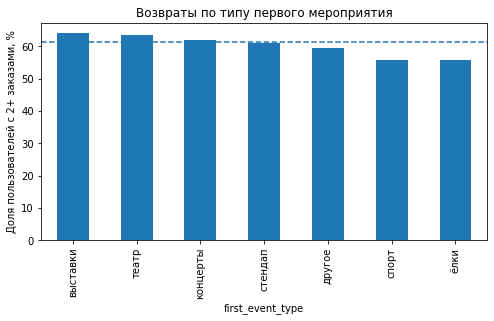

In [59]:
event_return.plot(
    x='first_event_type',
    y='return_rate',
    kind='bar',
    legend=False,
    figsize=(8,4)
)

plt.axhline(
    user_profile['is_two'].mean()*100,
    linestyle='--'
)

plt.ylabel('Доля пользователей с 2+ заказами, %')
plt.title('Возвраты по типу первого мероприятия')
plt.show()

In [60]:
device_return = (
    user_profile
    .groupby('first_device')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

device_return['return_rate'] *= 100

device_return

,first_device,users,return_rate
0,desktop,3714,63.812601
1,mobile,17924,60.812319


In [61]:
top_regions = (
    user_profile['first_region']
    .value_counts()
    .head(10)
    .index
)

region_return = (
    user_profile[
        user_profile['first_region'].isin(top_regions)
    ]
    .groupby('first_region')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
    .sort_values('return_rate', ascending=False)
)

region_return['return_rate'] *= 100

region_return

,first_region,users,return_rate
7,Шанырский регион,500,67.200000
4,Светополянский округ,457,65.645514
8,Широковская область,1224,64.542484
5,Североярская область,3767,63.817361
3,Речиновская область,440,63.409091
0,Каменевский регион,7085,62.399435
6,Травяная область,488,61.475410
9,Яблоневская область,411,59.367397
1,Малиновоярский округ,525,56.000000
2,Озернинский край,675,55.259259


In [62]:
top_services = (
    user_profile['first_service']
    .value_counts()
    .head(10)
    .index
)

service_return = (
    user_profile[
        user_profile['first_service'].isin(top_services)
    ]
    .groupby('first_service')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
    .sort_values('return_rate', ascending=False)
)

service_return['return_rate'] *= 100

service_return

,first_service,users,return_rate
4,Край билетов,454,65.198238
3,Дом культуры,356,64.606742
2,Весь в билетах,1285,62.879377
1,Билеты в руки,2559,62.719812
9,Прачечная,583,62.607204
8,Облачко,2177,61.276987
6,Лучшие билеты,1184,61.233108
5,Лови билет!,2809,60.911356
7,Мой билет,2969,60.862243
0,Билеты без проблем,5186,60.412649


> #### Вывод
>
> Для оценки влияния характеристик первого заказа на дальнейшее поведение пользователей была рассчитана доля клиентов, совершивших два и более заказа, в разрезе основных сегментов.
>
> Средняя доля пользователей, вернувшихся на платформу и совершивших повторный заказ, составила **61,3%**.
>
> Анализ по типу первого мероприятия показал, что наиболее высокая доля возврата наблюдается среди пользователей, впервые посетивших **выставки** (**64,0%**) и **театральные мероприятия** (**63,4%**). Пользователи, начавшие знакомство с платформой через концерты, также демонстрируют возврат выше среднего (**61,8%**). Наиболее низкие показатели наблюдаются у категорий **спорт** (**55,8%**) и **ёлки** (**55,8%**), однако категория «ёлки» представлена всего 95 пользователями, поэтому её результаты следует интерпретировать с осторожностью.
>
> По типу устройства различия также присутствуют. Пользователи, совершившие первый заказ с компьютера, возвращаются чаще (**63,8%**) по сравнению с пользователями мобильных устройств (**60,8%**). Однако основная часть аудитории приходит именно через мобильный канал, поэтому даже небольшие изменения показателей мобильных пользователей могут существенно влиять на общие результаты платформы.
>
> Среди регионов заметны различия в уровне возврата пользователей. Наиболее высокие показатели демонстрируют **Шанырский регион** (**67,2%**), **Светополянский округ** (**65,6%**) и **Широковская область** (**64,5%**). В то же время крупные регионы с большим количеством пользователей, такие как **Каменевский регион** (**62,4%**) и **Североярская область** (**63,8%**), также показывают возврат выше среднего по выборке, что делает их особенно интересными для дальнейшего анализа.
>
> Анализ билетных операторов показал, что лучшие показатели возврата демонстрируют пользователи, впервые совершившие покупку через операторов **«Край билетов»** (**65,2%**) и **«Дом культуры»** (**64,6%**). Однако данные сегменты относительно небольшие по объёму. Среди крупных операторов наиболее высокие показатели наблюдаются у **«Весь в билетах»** (**62,9%**) и **«Билеты в руки»** (**62,7%**).
>
> Таким образом, в данных действительно наблюдаются успешные «точки входа» на платформу. Наиболее перспективными выглядят пользователи, которые начинают пользоваться сервисом через театральные постановки и выставки, а также через ряд регионов и билетных операторов с устойчиво высокой долей повторных покупок. При этом наиболее надёжными для интерпретации следует считать сегменты с большим количеством пользователей, поскольку результаты небольших групп могут быть менее устойчивыми.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [63]:
event_return[
    event_return['first_event_type'].isin(
        ['спорт', 'концерты']
    )
]

,first_event_type,users,return_rate
2,концерты,9560,61.830544
3,спорт,794,55.793451


> #### Проверка гипотезы 1
>
> **Гипотеза:** пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
>
> Проведённый анализ не подтвердил данную гипотезу. Среди пользователей, впервые посетивших спортивные мероприятия, доля клиентов, совершивших два и более заказа, составила **55,8%**. Для пользователей, начавших пользоваться платформой через концертные мероприятия, аналогичный показатель оказался выше и достиг **61,8%**.
>
> Полученные результаты свидетельствуют о том, что концертные мероприятия являются более эффективной точкой входа для формирования повторных покупок, чем спортивные события. Таким образом, гипотеза о более высокой склонности к возврату пользователей спортивных мероприятий не нашла подтверждения в исследуемых данных.

In [64]:
region_return

,first_region,users,return_rate
7,Шанырский регион,500,67.200000
4,Светополянский округ,457,65.645514
8,Широковская область,1224,64.542484
5,Североярская область,3767,63.817361
3,Речиновская область,440,63.409091
0,Каменевский регион,7085,62.399435
6,Травяная область,488,61.475410
9,Яблоневская область,411,59.367397
1,Малиновоярский округ,525,56.000000
2,Озернинский край,675,55.259259


> #### Проверка гипотезы 2
>
> **Гипотеза:** в регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.
>
> Результаты анализа позволяют считать данную гипотезу **частично подтверждённой**. Крупнейшие регионы по числу пользователей действительно демонстрируют показатели возврата выше среднего уровня по выборке (**61,3%**). Так, доля пользователей, совершивших два и более заказа, составила **62,4%** в Каменевском регионе, **63,8%** в Североярской области и **64,5%** в Широковской области.
>
> Вместе с тем высокий уровень возврата наблюдается не только в крупнейших регионах. Например, в Шанырском регионе доля повторных заказов достигла **67,2%**, несмотря на значительно меньший размер сегмента. Это говорит о том, что количество пользователей в регионе не является единственным фактором, влияющим на вероятность возврата.
>
> Таким образом, наиболее крупные регионы действительно характеризуются высокой долей повторных заказов, однако связь между размером региона и возвратом пользователей нельзя считать однозначной. Для объяснения различий между регионами требуется дополнительный анализ других факторов, влияющих на поведение пользователей.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [65]:
one_order = user_profile[user_profile['is_two'] == 0]

returned = user_profile[user_profile['is_two'] == 1]

In [66]:
one_order['avg_revenue'].describe()

count    8368.000000
mean      545.295642
std       519.514097
min       -10.770000
25%       132.070000
50%       378.030000
75%       830.317500
max      2628.421739
Name: avg_revenue, dtype: float64

In [67]:
returned['avg_revenue'].describe()

count    13270.000000
mean       544.337170
std        369.354468
min         -5.385000
25%        270.814375
50%        495.772429
75%        745.165500
max       2628.421739
Name: avg_revenue, dtype: float64

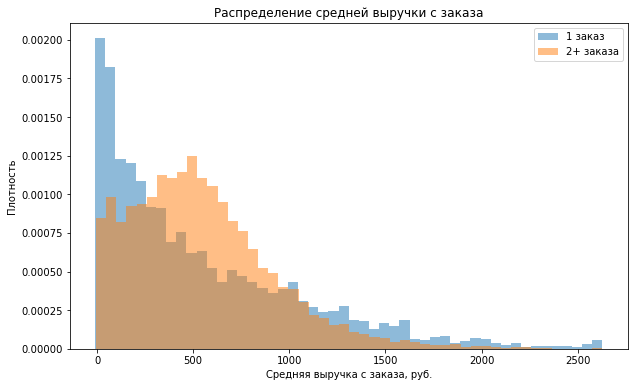

In [68]:
plt.figure(figsize=(10, 6))

plt.hist(
    one_order['avg_revenue'],
    bins=50,
    alpha=0.5,
    density=True,
    label='1 заказ'
)

plt.hist(
    returned['avg_revenue'],
    bins=50,
    alpha=0.5,
    density=True,
    label='2+ заказа'
)

plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки с заказа')
plt.legend()

plt.show()

In [69]:
comparison = pd.DataFrame({
    'group': ['1 заказ', '2+ заказа'],
    'mean': [
        one_order['avg_revenue'].mean(),
        returned['avg_revenue'].mean()
    ],
    'median': [
        one_order['avg_revenue'].median(),
        returned['avg_revenue'].median()
    ]
})

comparison

,group,mean,median
0,1 заказ,545.295642,378.030000
1,2+ заказа,544.337170,495.772429


> #### Вывод
>
> Для оценки связи между размером заказа и вероятностью возврата пользователей были проанализированы распределения средней выручки с заказа для двух групп: пользователей, совершивших только один заказ, и пользователей, совершивших два и более заказа.
>
> Средние значения выручки в группах оказались практически одинаковыми: **545 руб.** для пользователей с одним заказом и **544 руб.** для пользователей, совершивших повторные покупки. Однако анализ медианных значений выявил заметные различия. Медианная выручка пользователей с одним заказом составила **378 руб.**, тогда как для вернувшихся пользователей она достигла **496 руб.**
>
> Это говорит о том, что среди пользователей, которые возвращаются на платформу, чаще встречаются клиенты с более высокой типичной стоимостью заказа. При этом в группе пользователей с одним заказом присутствует некоторое количество дорогих покупок, которые увеличивают среднее значение и скрывают различия между группами.
>
> Визуальный анализ распределений показывает, что пользователи обеих групп в основном концентрируются в диапазоне относительно невысоких значений средней выручки. Однако распределение вернувшихся пользователей смещено в сторону более высоких значений, что может свидетельствовать о положительной связи между размером заказа и вероятностью повторной покупки.
>
> Таким образом, данные позволяют предположить, что пользователи с более высокой средней стоимостью заказа в целом чаще возвращаются на платформу, хотя данная связь не является очень сильной.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [70]:
orders_2_4 = user_profile[
    (user_profile['orders_count'] >= 2)
    & (user_profile['orders_count'] <= 4)
]

orders_5_plus = user_profile[
    user_profile['orders_count'] >= 5
]

In [71]:
orders_2_4['avg_revenue'].describe()

count    7147.000000
mean      551.572386
std       420.197691
min        -5.385000
25%       218.428750
50%       471.266667
75%       798.550000
max      2628.421739
Name: avg_revenue, dtype: float64

In [72]:
orders_5_plus['avg_revenue'].describe()

count    6123.000000
mean      535.891950
std       299.089582
min         0.000000
25%       330.456122
50%       512.650613
75%       700.809038
max      2299.869022
Name: avg_revenue, dtype: float64

In [73]:
comparison_orders = pd.DataFrame({
    'group': ['2-4 заказа', '5+ заказов'],
    'mean': [
        orders_2_4['avg_revenue'].mean(),
        orders_5_plus['avg_revenue'].mean()
    ],
    'median': [
        orders_2_4['avg_revenue'].median(),
        orders_5_plus['avg_revenue'].median()
    ]
})

comparison_orders

,group,mean,median
0,2-4 заказа,551.572386,471.266667
1,5+ заказов,535.891950,512.650613


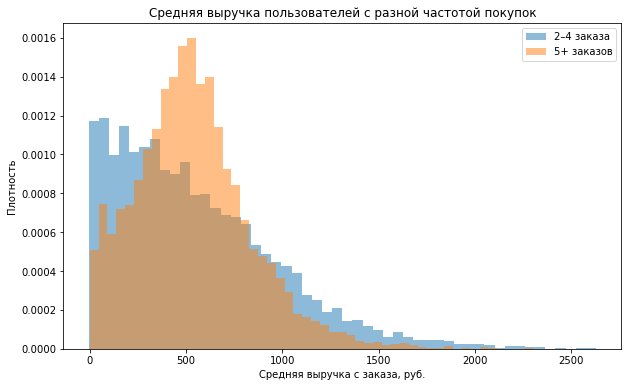

In [74]:
plt.figure(figsize=(10, 6))

plt.hist(
    orders_2_4['avg_revenue'],
    bins=50,
    alpha=0.5,
    density=True,
    label='2–4 заказа'
)

plt.hist(
    orders_5_plus['avg_revenue'],
    bins=50,
    alpha=0.5,
    density=True,
    label='5+ заказов'
)

plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.title('Средняя выручка пользователей с разной частотой покупок')
plt.legend()

plt.show()

> #### Вывод
>
> Для сравнения были проанализированы распределения средней выручки с заказа у пользователей, совершивших **2–4 заказа**, и у пользователей, совершивших **5 и более заказов**.
>
> Средние значения выручки в группах отличаются незначительно: **552 рубля** для пользователей с 2–4 заказами и **536 рублей** для пользователей с 5 и более заказами. Однако медианные значения показывают иную картину: **471 рубль** и **513 рублей** соответственно.
>
> Визуальный анализ распределений подтверждает данный результат. Распределение пользователей с 5 и более заказами смещено в сторону более высоких значений средней выручки, а наибольшая концентрация таких пользователей наблюдается в диапазоне примерно **400–600 рублей** за заказ. В группе пользователей с 2–4 заказами чаще встречаются более низкие значения средней выручки.
>
> При этом у пользователей с 2–4 заказами наблюдается более длинный правый хвост распределения, что свидетельствует о наличии отдельных пользователей с очень высокими средними чеками. Именно эти наблюдения повышают среднее значение выручки и объясняют расхождение между средними и медианными показателями.
>
> Таким образом, наиболее лояльные пользователи (**5 и более заказов**) характеризуются несколько более высоким типичным уровнем расходов на заказ. Это подтверждается медианной выручкой (**513 рублей** против **471 рубля** у пользователей с 2–4 заказами) и формой распределения. Однако различия между группами нельзя назвать существенными, поэтому влияние размера заказа на частоту возврата выглядит **умеренным**.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

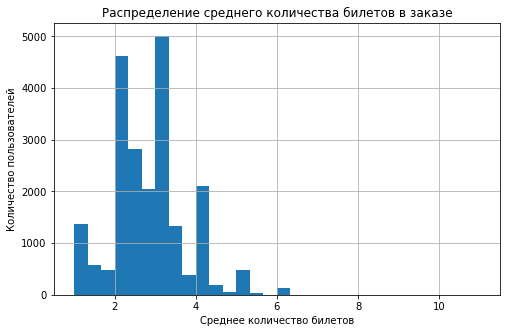

In [75]:
plt.figure(figsize=(8, 5))

user_profile['avg_tickets'].hist(
    bins=30
)

plt.title('Распределение среднего количества билетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')

plt.show()

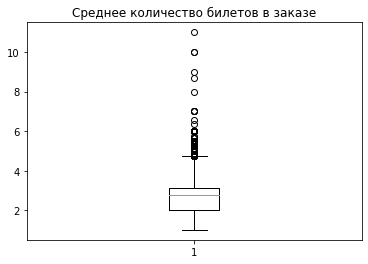

In [76]:
plt.figure(figsize=(6, 4))

plt.boxplot(user_profile['avg_tickets'])

plt.title('Среднее количество билетов в заказе')

plt.show()

In [77]:
user_profile['tickets_segment'] = pd.cut(
    user_profile['avg_tickets'],
    bins=[1, 2, 3, 5, float('inf')],
    labels=[
        '1-2 билета',
        '2-3 билета',
        '3-5 билетов',
        '5+ билетов'
    ],
    include_lowest=True
)

In [78]:
user_profile['tickets_segment'].value_counts()

2-3 билета     9935
1-2 билета     6160
3-5 билетов    5349
5+ билетов      194
Name: tickets_segment, dtype: int64

In [79]:
tickets_analysis = (
    user_profile
    .groupby('tickets_segment')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

tickets_analysis['share_users'] = (
    tickets_analysis['users']
    / tickets_analysis['users'].sum()
    * 100
)

tickets_analysis['return_rate'] = (
    tickets_analysis['return_rate']
    * 100
)

tickets_analysis

,tickets_segment,users,return_rate,share_users
0,1-2 билета,6160,40.146104,28.468435
1,2-3 билета,9935,74.282838,45.914595
2,3-5 билетов,5349,62.703309,24.720399
3,5+ билетов,194,32.474227,0.896571


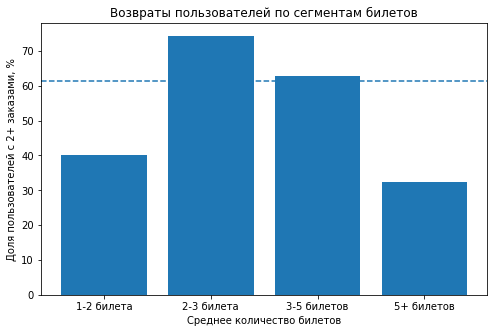

In [80]:
plt.figure(figsize=(8, 5))

plt.bar(
    tickets_analysis['tickets_segment'],
    tickets_analysis['return_rate']
)

plt.axhline(
    user_profile['is_two'].mean() * 100,
    linestyle='--'
)

plt.ylabel('Доля пользователей с 2+ заказами, %')
plt.xlabel('Среднее количество билетов')
plt.title('Возвраты пользователей по сегментам билетов')

plt.show()

> #### Вывод
>
> Анализ распределения пользователей по среднему количеству билетов в заказе показал, что пользователи распределены между сегментами неравномерно. Наиболее массовым является сегмент **2–3 билета**, на который приходится **9 935 пользователей** или **45,9%** выборки. Далее следуют сегменты **1–2 билета** (**28,5%**) и **3–5 билетов** (**24,7%**). Пользователи со средним количеством билетов **5 и более** встречаются крайне редко и составляют менее **1%** выборки.
>
> Между сегментами наблюдаются существенные различия по доле повторных покупок. Наиболее высокий показатель возврата демонстрируют пользователи, которые в среднем приобретают **от 2 до 3 билетов** на заказ: доля пользователей с двумя и более заказами составляет **74,3%**, что значительно выше среднего уровня по выборке (**61,3%**).
>
> Пользователи, покупающие в среднем **от 3 до 5 билетов**, также демонстрируют высокий уровень возврата — **62,7%**, что немного превышает среднее значение.
>
> Наиболее низкие показатели наблюдаются в сегментах **1–2 билета** (**40,1%**) и **5 и более билетов** (**32,5%**). Однако последний сегмент включает всего **194 пользователя**, поэтому его результаты могут быть нестабильными и требуют осторожной интерпретации.
>
> Полученные результаты позволяют предположить, что наиболее лояльной аудиторией являются пользователи, которые обычно приобретают **2–3 билета** за один заказ. Напротив, пользователи, покупающие в среднем не более двух билетов, возвращаются на платформу существенно реже. Таким образом, среднее количество билетов в заказе может быть важным фактором, связанным с вероятностью повторной покупки.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [81]:
user_profile['first_weekday'] = (
    user_profile['first_order_date']
    .dt.day_name()
)

In [82]:
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

In [83]:
weekday_analysis = (
    user_profile
    .groupby('first_weekday')
    .agg(
        users=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

weekday_analysis['return_rate'] *= 100

weekday_analysis['first_weekday'] = pd.Categorical(
    weekday_analysis['first_weekday'],
    categories=weekday_order,
    ordered=True
)

weekday_analysis = weekday_analysis.sort_values(
    'first_weekday'
)

weekday_analysis

,first_weekday,users,return_rate
1,Monday,2930,63.037543
5,Tuesday,3176,61.901763
6,Wednesday,3057,62.185149
4,Thursday,3113,59.428204
0,Friday,3259,59.834305
2,Saturday,3326,62.808178
3,Sunday,2777,60.028808


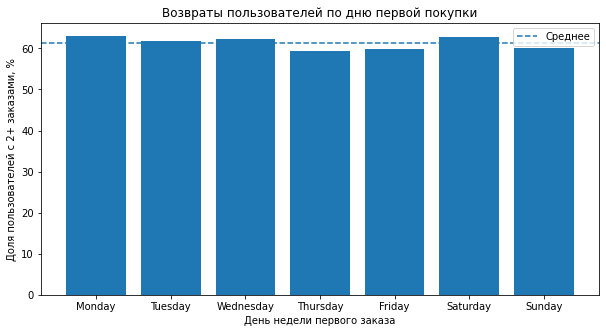

In [84]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_analysis['first_weekday'],
    weekday_analysis['return_rate']
)

plt.axhline(
    user_profile['is_two'].mean() * 100,
    linestyle='--',
    label='Среднее'
)

plt.ylabel('Доля пользователей с 2+ заказами, %')
plt.xlabel('День недели первого заказа')
plt.title('Возвраты пользователей по дню первой покупки')

plt.legend()
plt.show()

In [85]:
weekday_analysis['share_users'] = (
    weekday_analysis['users']
    / weekday_analysis['users'].sum()
    * 100
)

weekday_analysis

,first_weekday,users,return_rate,share_users
1,Monday,2930,63.037543,13.540993
5,Tuesday,3176,61.901763,14.677882
6,Wednesday,3057,62.185149,14.127923
4,Thursday,3113,59.428204,14.386727
0,Friday,3259,59.834305,15.061466
2,Saturday,3326,62.808178,15.371106
3,Sunday,2777,60.028808,12.833903


> #### Вывод
>
> Для оценки влияния дня недели первого заказа на вероятность возврата пользователей был проведён анализ распределения клиентов и доли повторных покупок по дням недели.
>
> Пользователи распределены между днями недели достаточно равномерно. Доля пользователей, совершивших первый заказ в каждый из дней недели, находится в диапазоне от **12,8%** до **15,4%** выборки. Наибольшее число первых заказов приходится на **субботу** (**15,4%**) и **пятницу** (**15,1%**), а наименьшее — на **воскресенье** (**12,8%**).
>
> Доля пользователей, совершивших повторный заказ, также отличается незначительно. Наиболее высокий показатель возврата наблюдается у пользователей, совершивших первую покупку в **понедельник** (**63,0%**) и **субботу** (**62,8%**). Наиболее низкие значения зафиксированы для **четверга** (**59,4%**) и **пятницы** (**59,8%**).
>
> При среднем уровне возврата по выборке **61,3%** различия между днями недели составляют менее **4 процентных пунктов**. Это свидетельствует о том, что день недели первого заказа оказывает лишь слабое влияние на вероятность повторной покупки.
>
> Таким образом, в исследуемых данных не наблюдается выраженных «удачных» или «неудачных» дней недели для привлечения пользователей. Вероятность возврата клиентов остаётся относительно стабильной независимо от дня совершения первой покупки.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [86]:
orders_2_4 = user_profile[
    (user_profile['orders_count'] >= 2)
    & (user_profile['orders_count'] <= 4)
]

orders_5_plus = user_profile[
    user_profile['orders_count'] >= 5
]

In [87]:
orders_2_4['avg_days_between'].describe()

count    7147.000000
mean       21.317884
std        28.480058
min         0.000000
25%         0.000000
50%         9.000000
75%        34.000000
max       148.000000
Name: avg_days_between, dtype: float64

In [88]:
orders_5_plus['avg_days_between'].describe()

count    6123.000000
mean        9.901352
std         7.803757
min         0.000000
25%         3.884034
50%         8.117647
75%        14.118056
max        37.500000
Name: avg_days_between, dtype: float64

In [89]:
days_comparison = pd.DataFrame({
    'group': ['2-4 заказа', '5+ заказов'],
    'mean_days': [
        orders_2_4['avg_days_between'].mean(),
        orders_5_plus['avg_days_between'].mean()
    ],
    'median_days': [
        orders_2_4['avg_days_between'].median(),
        orders_5_plus['avg_days_between'].median()
    ]
})

days_comparison

,group,mean_days,median_days
0,2-4 заказа,21.317884,9.000000
1,5+ заказов,9.901352,8.117647


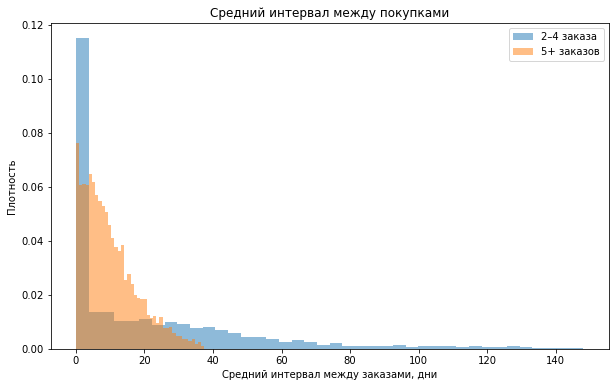

In [90]:
plt.figure(figsize=(10, 6))

plt.hist(
    orders_2_4['avg_days_between'].dropna(),
    bins=40,
    alpha=0.5,
    density=True,
    label='2–4 заказа'
)

plt.hist(
    orders_5_plus['avg_days_between'].dropna(),
    bins=40,
    alpha=0.5,
    density=True,
    label='5+ заказов'
)

plt.xlabel('Средний интервал между заказами, дни')
plt.ylabel('Плотность')
plt.title('Средний интервал между покупками')
plt.legend()

plt.show()

> #### Вывод
>
> Для оценки влияния частоты взаимодействия с сервисом были проанализированы средние интервалы между заказами у пользователей, совершивших **2–4 заказа**, и пользователей, совершивших **5 и более заказов**.
>
> Анализ показал существенные различия между группами. Для пользователей с 2–4 заказами средний интервал между покупками составил **21,3 дня**, тогда как для пользователей с 5 и более заказами — всего **9,9 дня**. Таким образом, наиболее лояльные пользователи совершают покупки более чем в два раза чаще.
>
> Медианные значения также подтверждают данную закономерность: **9,0 дней** для пользователей с 2–4 заказами против **8,1 дня** для пользователей с 5 и более заказами. Несмотря на относительно близкие медианные значения, распределение пользователей с 2–4 заказами имеет значительно более длинный правый хвост, что указывает на наличие большого числа пользователей с длительными перерывами между покупками.
>
> Визуальный анализ распределений показывает, что пользователи с 5 и более заказами сконцентрированы в области небольших интервалов между покупками, тогда как среди пользователей с 2–4 заказами значительно чаще встречаются длительные периоды отсутствия активности.
>
> Полученные результаты свидетельствуют о наличии выраженной связи между частотой покупок и удержанием пользователей. Чем меньше времени проходит между заказами, тем выше вероятность того, что пользователь продолжит пользоваться сервисом и совершит большое количество покупок в будущем.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [91]:
user_profile['orders_segment'] = pd.cut(
    user_profile['orders_count'],
    bins=[0, 1, 4, float('inf')],
    labels=[
        '1 заказ',
        '2-4 заказа',
        '5+ заказов'
    ]
)

In [92]:
user_profile['orders_segment'].value_counts()

1 заказ       8368
2-4 заказа    7147
5+ заказов    6123
Name: orders_segment, dtype: int64

In [93]:
corr_df = user_profile[
    [
        'orders_segment',
        'first_device',
        'first_region',
        'first_service',
        'first_event_type',
        'avg_revenue',
        'avg_tickets',
        'avg_days_between'
    ]
]

In [94]:
phik_corr = corr_df.phik_matrix(
    interval_cols=[
        'avg_revenue',
        'avg_tickets',
        'avg_days_between'
    ]
)

In [95]:
%pip install "scipy==1.10.1" --force-reinstall

  Using cached scipy-1.10.1-cp39-cp39-macosx_10_9_x86_64.whl (35.2 MB)
  Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl (20.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scipy
    Found existing installation: scipy 1.10.1
    Uninstalling scipy-1.10.1:
      Successfully uninstalled scipy-1.10.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.3.0 requires daal==2021.2.3, which is not installed.
numba 0.54.1 requires numpy<1.21,>=1.17, but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [96]:
import phik
print(phik.__version__)

0.12.5


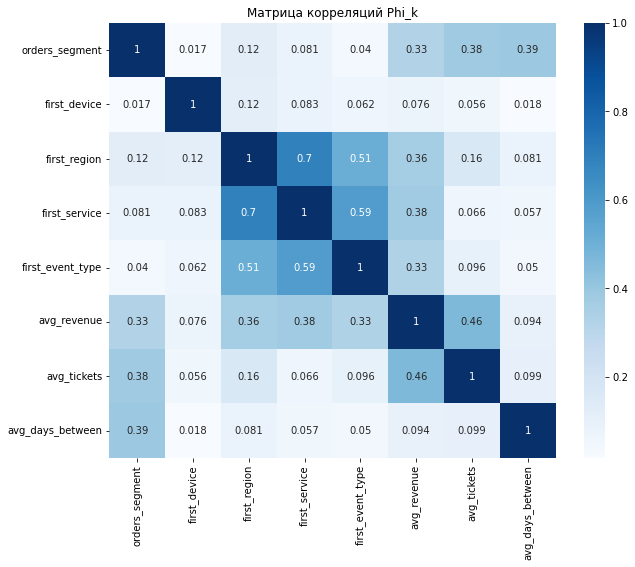

In [97]:
plt.figure(figsize=(10,8))

sns.heatmap(
    phik_corr,
    annot=True,
    cmap='Blues'
)

plt.title('Матрица корреляций Phi_k')

plt.show()

In [98]:
phik_corr['orders_segment'].sort_values(
    ascending=False
)

orders_segment      1.000000
avg_days_between    0.390127
avg_tickets         0.383366
avg_revenue         0.326091
first_region        0.123473
first_service       0.081308
first_event_type    0.040322
first_device        0.017110
Name: orders_segment, dtype: float64

> #### Вывод
>
> Для оценки факторов, связанных с количеством заказов пользователей, был проведён корреляционный анализ с использованием коэффициента **Phi_k**, который позволяет одновременно анализировать числовые и категориальные признаки.
>
> Поскольку распределение количества заказов было сильно смещено в сторону небольших значений, пользователи были предварительно разделены на три сегмента:
>
> - **1 заказ**;
> - **2–4 заказа**;
> - **5 и более заказов**.
>
> Полученные коэффициенты корреляции показали, что наиболее сильная связь с количеством заказов наблюдается у следующих признаков:
>
> | Признак | Phi_k |
> |----------|----------:|
> | **Средний интервал между заказами** (`avg_days_between`) | **0,39** |
> | **Среднее количество билетов в заказе** (`avg_tickets`) | **0,38** |
> | **Средняя выручка с заказа** (`avg_revenue`) | **0,33** |
>
> Полученные значения свидетельствуют о наличии умеренной связи между этими показателями и количеством заказов пользователя.
>
> Среди категориальных признаков наиболее заметную связь показал регион первого заказа (**0,12**), однако данное значение существенно ниже, чем у количественных характеристик поведения пользователей. Связь количества заказов с билетным оператором (**0,08**), типом первого мероприятия (**0,04**) и устройством первого заказа (**0,02**) оказалась слабой.
>
> Таким образом, наибольшую связь с количеством заказов демонстрируют не характеристики первого контакта пользователя с сервисом, а его последующее поведение. Пользователи, которые чаще совершают покупки, приобретают больше билетов за заказ и характеризуются более высокой средней выручкой, как правило, совершают большее количество заказов в течение рассматриваемого периода.
>
> Полученные результаты согласуются с предыдущими этапами анализа, где наиболее выраженные различия между группами пользователей также наблюдались по интервалу между покупками и количеству приобретаемых билетов.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

---

#### Общий вывод

В ходе исследования были проанализированы данные о заказах пользователей сервиса Яндекс Афиша за период с июня по октябрь 2024 года. На этапе подготовки данных были исключены заказы с редких типов устройств и покупки билетов на фильмы, выручка была приведена к единой валюте (рублям), а выбросы по выручке выше 99-го перцентиля были удалены. После предобработки в анализе использовались данные по **21 638 пользователям** и **287 786 заказам**.

Анализ показал, что пользователи распределены по количеству заказов неравномерно. **38,7%** пользователей совершили только один заказ, **33,0%** — от двух до четырёх заказов, а **28,3%** — пять и более заказов. Доля пользователей, совершивших повторную покупку, составила **61,3%**, что свидетельствует о достаточно высоком уровне удержания аудитории.

Среди характеристик первого заказа наиболее высокий уровень возврата продемонстрировали пользователи, впервые посетившие **выставки (64,0%)**, **театр (63,4%)** и **концерты (61,8%)**. Гипотеза о том, что пользователи спортивных мероприятий возвращаются чаще пользователей концертов, не подтвердилась: доля повторных покупок составила **55,8%** против **61,8%** соответственно. Влияние типа устройства первого заказа оказалось слабым: пользователи компьютеров возвращались лишь немного чаще пользователей мобильных устройств. Аналогично, день недели первой покупки практически не влияет на вероятность возврата — доля повторных покупок по дням недели варьируется от **59,4%** до **63,0%**.

Анализ количественных характеристик заказов показал, что пользователи с повторными покупками характеризуются более высокой медианной выручкой с заказа (**496 рублей** против **378 рублей** у пользователей с одним заказом), однако влияние размера заказа на вероятность возврата выглядит умеренным.

Более выраженная связь наблюдается для количества билетов в заказе. Наиболее высокий уровень возврата демонстрируют пользователи, приобретающие в среднем **2–3 билета за заказ**: доля повторных покупок в данном сегменте достигает **74,3%**, что значительно превышает среднее значение по выборке. При этом данный сегмент является самым многочисленным и охватывает **45,9% пользователей**.

Среди временных характеристик наиболее заметное влияние оказывает интервал между покупками. Пользователи, совершившие **5 и более заказов**, имеют средний интервал между заказами **9,9 дня**, тогда как для пользователей с **2–4 заказами** этот показатель составляет **21,3 дня**. Это свидетельствует о тесной связи между частотой покупок и удержанием пользователей.

Результаты корреляционного анализа подтвердили данные выводы. Наиболее сильную связь с количеством заказов показали:

- средний интервал между покупками (**Phi_k = 0,39**);
- среднее количество билетов в заказе (**Phi_k = 0,38**);
- средняя выручка с заказа (**Phi_k = 0,33**).

Связь количества заказов с характеристиками первого заказа оказалась значительно слабее. Среди них наиболее заметное влияние показал только регион первого заказа (**Phi_k = 0,12**), тогда как влияние устройства, билетного оператора и типа мероприятия оказалось минимальным.

#### Рекомендации

На основании проведённого анализа рекомендуется сосредоточить маркетинговые усилия на стимулировании второй покупки и сокращении интервала между заказами, поскольку именно частота взаимодействия с сервисом показала наиболее тесную связь с удержанием пользователей.

Особое внимание следует уделить пользователям, приобретающим **2–3 билета за заказ**. Этот сегмент является одновременно самым многочисленным (**45,9% пользователей**) и демонстрирует максимальную долю повторных покупок (**74,3%**), что делает его наиболее ценным для бизнеса.

Для привлечения новых пользователей перспективными точками входа выглядят **театральные мероприятия, концерты и выставки**, поскольку именно эти категории показали наиболее высокий уровень возврата аудитории.

При разработке моделей прогнозирования и программ удержания рекомендуется в первую очередь использовать поведенческие показатели пользователей — интервал между покупками, количество билетов в заказе и среднюю выручку, так как именно эти признаки продемонстрировали наиболее сильную связь с количеством заказов.